## The Greedy Algorthm
This notebook is comparing the performance of the greedy algorithm with number of agents.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np

from utils.environment import Environment
from main import simulate_greedy_evacuation

n_experiments = 10
num_agents = 20
params = {"congestion": True, "walking": False, "fitness": "max"}

In [4]:
grid_city = Environment('grid_city')
moderate_city = Environment('moderate_city')
bottleneck_city = Environment('bottleneck_city')

In [5]:
rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

### Grid City

In [ ]:
num_agents = [10, 20, 30, 40, 50, 100, 200]
grid_city_solutions, grid_city_eval = {n: [] for n in num_agents}, {n: [] for n in num_agents}
for n in num_agents:
    for seed in algorithm_seeds:
        solution, evals = simulate_greedy_evacuation(
            num_agents=n,
            simulation_params=params,
            city=grid_city,
            seed=seed,
            verbose=False
        )
        grid_city_solutions[n].append(solution)
        grid_city_eval[n].append(evals)
    print(f'✅ {n} AGENTS')

✅ 10 AGENTS
✅ 20 AGENTS
✅ 30 AGENTS
✅ 40 AGENTS
✅ 50 AGENTS
✅ 100 AGENTS
✅ 200 AGENTS


In [10]:
grid_city_eval[10][0].metrics

{'Avg path length': np.float64(5.0),
 'Total time': np.int64(5),
 'Average time': np.float64(5.0),
 'Congestion index': np.float64(0.0),
 'Avg Congestion delay': np.float64(0.0),
 'Exit utilisation': np.float64(0.3333333333333333),
 'Avg Path Efficiency': np.float64(1.0)}

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_greedy_scaling(results: dict):
    agent_counts = sorted(results.keys())
    
    metrics = ["Total time", "Average time", "Avg Congestion delay"]
    labels = ["Total Time", "Avg Time", "Avg Congestion Delay"]
    colours = ["#378ADD", "#1D9E75", "#D85A30"]

    fig, ax = plt.subplots(figsize=(10, 6))

    for metric, label, colour in zip(metrics, labels, colours):
        means, stds = [], []
        for n in agent_counts:
            values = [d.metrics[metric] for d in results[n]]
            means.append(np.mean(values))
            stds.append(np.std(values))

        means, stds = np.array(means), np.array(stds)
        ax.plot(agent_counts, means, label=label, marker='o', color=colour)
        ax.fill_between(agent_counts, means - stds, means + stds, alpha=0.15, color=colour)

    ax.set_xlabel("Number of Agents")
    ax.set_ylabel("Timesteps")
    ax.set_title("Greedy Routing Performance vs Number of Agents")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

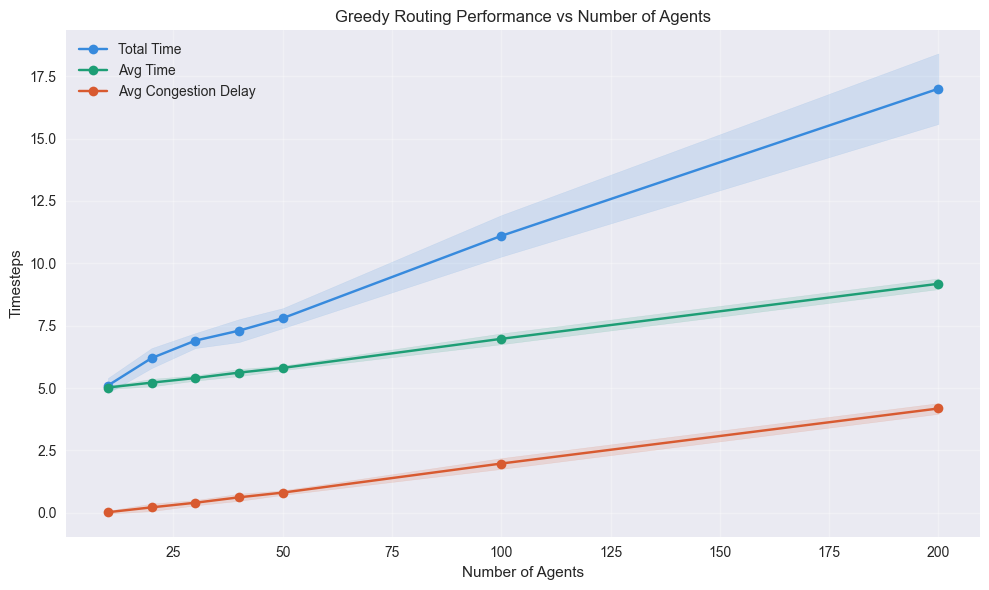

In [21]:
plot_greedy_scaling(grid_city_eval)